In [1]:
import sqlite3
import pandas as pd
from tqdm import tqdm
import powerlaw as pwl
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [2]:
source3 = pd.read_csv("graph_data_files/verbs_wcomps_obl_actor_root_perloc_counts.csv", sep=",", encoding="utf-8")

In [3]:
source3

,root_word,root_cnt,elus_cnt,mitte_elus_cnt
0,,5,0,0
1,%p2tu,1,0,0
2,%reimo,1,0,0
3,/O,2,0,0
4,/P,1,0,0
...,...,...,...,...
410714,█████████,1,0,0
410715,██████████,1,0,0
410716,□,2,0,0
410717,�,13,0,0


In [4]:
source3["elus_div"] = source3["elus_cnt"]/source3["root_cnt"]
source3["koht_div"] = source3["mitte_elus_cnt"]/source3["root_cnt"]

In [5]:
areadict = {}
root_cnts = sorted(list(set(list(source3["root_cnt"])))) 

for cnt in root_cnts:
    if cnt <10: areadict[cnt] = 5
    elif cnt >=10 and cnt < 100: areadict[cnt] = 10
    elif cnt >=100 and cnt < 1000: areadict[cnt] = 30
    #elif cnt >=500 and cnt < 1000: areadict[cnt] = 30
    elif cnt >=1000 and cnt < 5000: areadict[cnt] = 50
    #elif cnt >=2000 and cnt < 5000: areadict[cnt] = 80
    elif cnt >=5000 and cnt < 20000: areadict[cnt] = 80
    #elif cnt >=10000 and cnt < 15000: areadict[cnt] = 300
    elif cnt >=20000 and cnt < 50000: areadict[cnt] = 100
    elif cnt >=50000: areadict[cnt] = 200

# TAVAPLOT

### normaliseeritud väärtustega pilt

In [6]:
roots = list(source3["root_cnt"])
kohad =  list(source3["koht_div"])
elusad = list(source3["elus_div"])

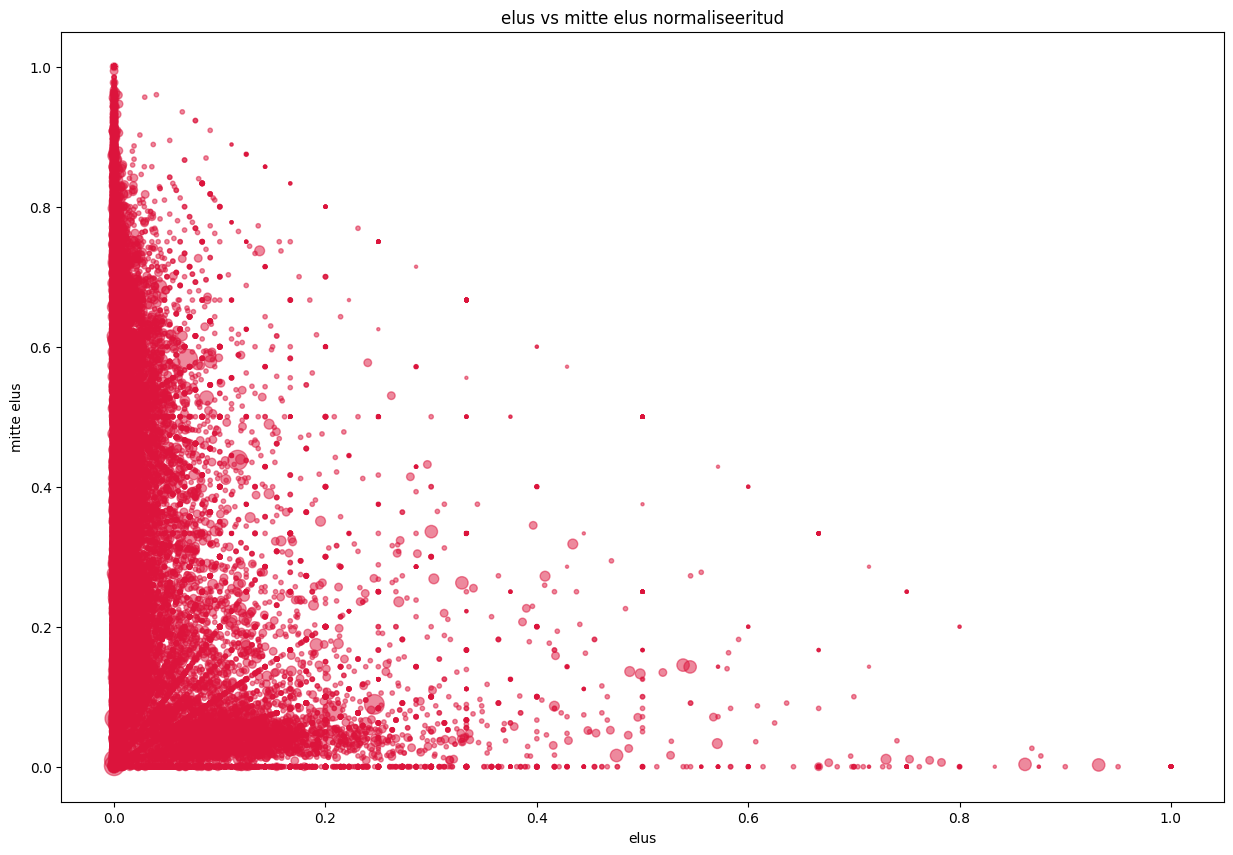

In [7]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs mitte elus normaliseeritud")
plt.ylabel("mitte elus")
plt.xlabel("elus")

plt.show()

### filter: root_cnt >=100

In [16]:
source4 = source3[source3["root_cnt"]>=100]

roots = list(source4["root_cnt"])
kohad =  list(source4["koht_div"])
elusad = list(source4["elus_div"])

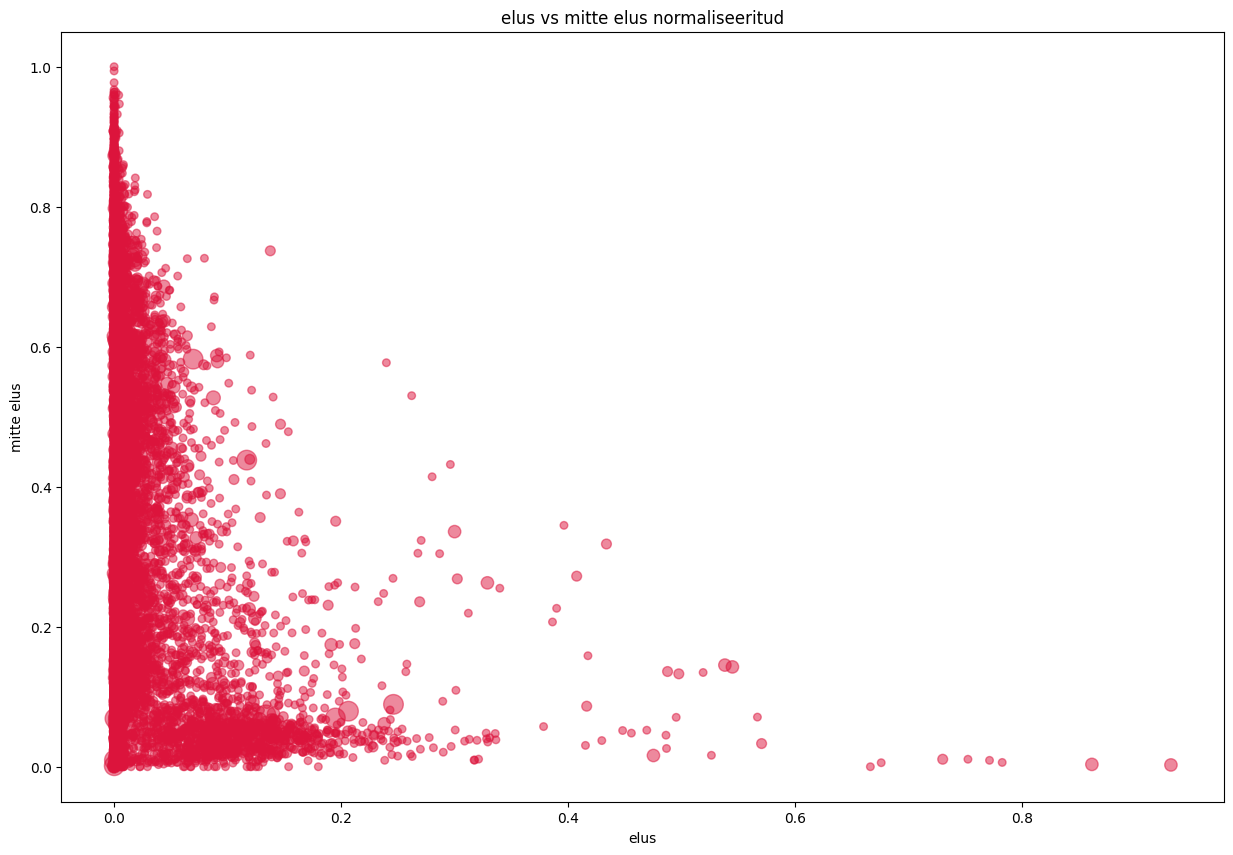

In [17]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs mitte elus normaliseeritud")
plt.ylabel("mitte elus")
plt.xlabel("elus")

plt.show()

### filter: root_cnt >=1000

In [18]:
source4 = source3[source3["root_cnt"]>=1000]

roots = list(source4["root_cnt"])
kohad =  list(source4["koht_div"])
elusad = list(source4["elus_div"])

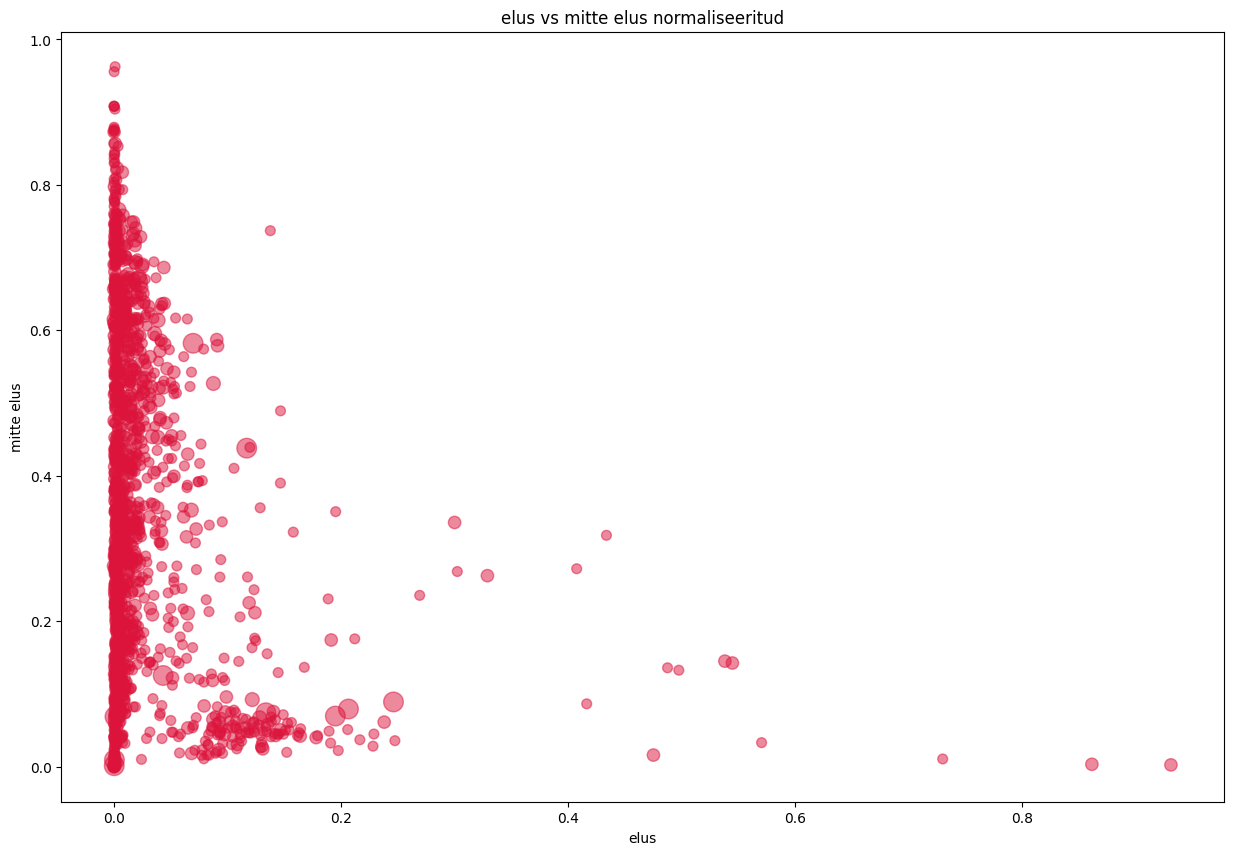

In [19]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs mitte elus normaliseeritud")
plt.ylabel("mitte elus")
plt.xlabel("elus")

plt.show()

### filter: root_cnt >=1000 & div suhe on 3:1

In [5]:
source4 = source3[source3["root_cnt"]>=1000]
source4 = source4[(source4["elus_div"]>=0.05) & (source4["koht_div"]>=0.05)]
source4 = source4[(source4["elus_div"]>=3*source4["koht_div"]) | (source4["koht_div"]>=3*source4["elus_div"])]

roots = list(source4["root_cnt"])
kohad =  list(source4["koht_div"])
elusad = list(source4["elus_div"])
names = list(source4["root_word"])

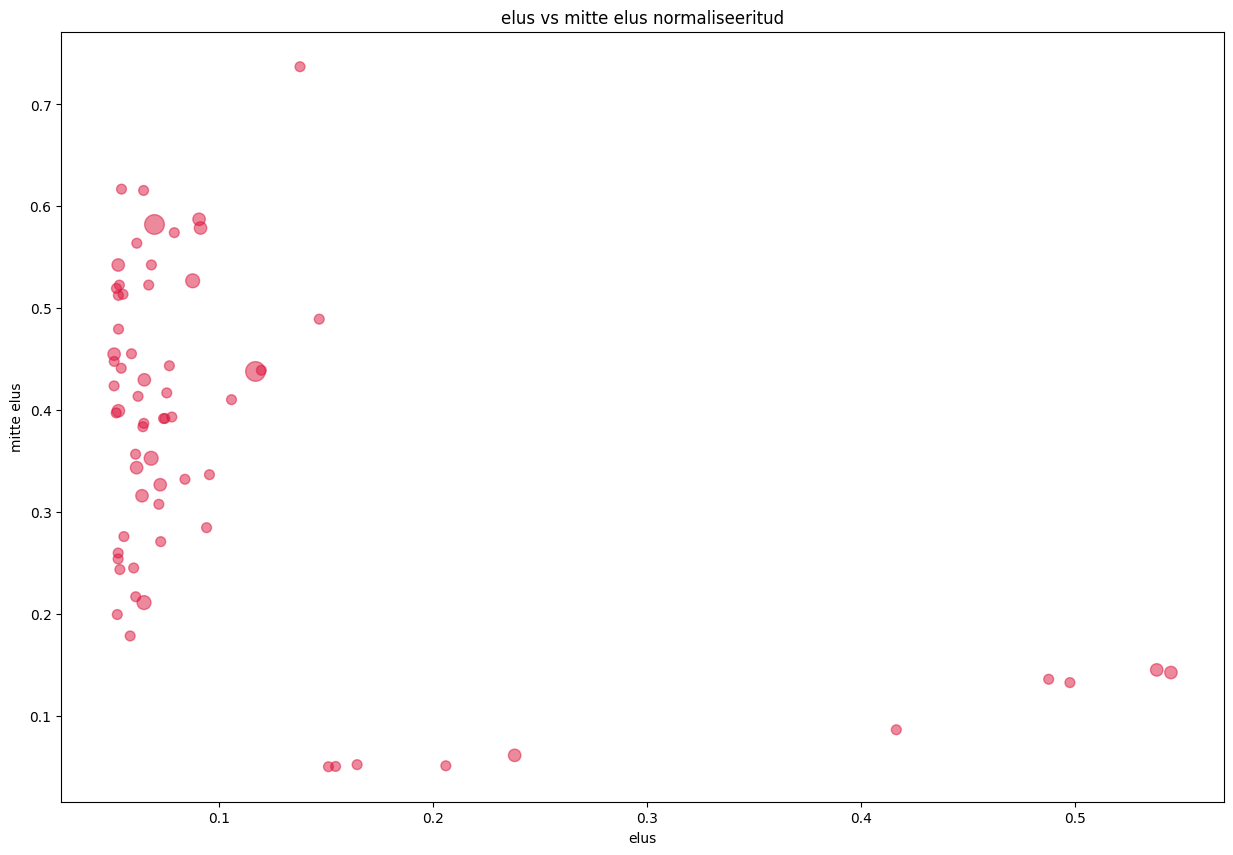

In [23]:
plt.figure(figsize=(15, 10))

x = elusad
y = kohad
area = [areadict[cnt] for cnt in roots]
plt.scatter(x, y, s=area, c='crimson', alpha=0.5)

plt.title("elus vs mitte elus normaliseeritud")
plt.ylabel("mitte elus")
plt.xlabel("elus")

plt.show()

# HOVER

# <font color='red'>to see hover plot run these cells</font>

In [8]:

import pandas as pd
import plotly.express as px

In [9]:
source3 = pd.read_csv("graph_data_files/verb_analysis_locative_per_vs_loc.csv", sep=",", encoding="utf-8")
source3["elus"] = source3["elus_cnt"]/source3["root_cnt"]
source3["mitte_elus"] = source3["mitte_elus_cnt"]/source3["root_cnt"]

In [10]:
# filter: root_cnt >=1000 & div suhe on 3:1

source4 = source3[source3["root_cnt"]>=1000]
source4 = source4[(source4["elus"]>=0.05) & (source4["mitte_elus"]>=0.05)]
source4 = source4[(source4["elus"]>=3*source4["mitte_elus"]) | (source4["mitte_elus"]>=3*source4["elus"])]

In [6]:
#source4.to_csv("graph_data_files/verb_analysis_locative_per_vs_loc.csv.csv", encoding="utf-8", index=False)

In [12]:
fig = px.scatter(source4, x='elus', y='mitte_elus', text='root_word')

# Update the layout to show the text on hover
fig.update_traces(marker=dict(size=12),
#selector=dict(mode='markers'),
selector=dict(type='scatter'),
)

fig.update_layout(hovermode='closest')
fig.write_html("verb_locative_per_vs_nonper.html")
fig.show()